# Notebook 02 — Baseline Model: TF-IDF Trend Detection

## Why TF-IDF as a Baseline?

**TF-IDF** (Term Frequency – Inverse Document Frequency) is the standard first-pass model for text corpora because:

| Criterion | Advantage |
|---|---|
| **No training data** | Unsupervised; works immediately on any corpus |
| **Interpretable** | Output is a ranked list of terms — humans can verify it |
| **Handles document length** | Normalises for short vs. long headlines equally |
| **Penalises common words** | IDF down-weights 'said', 'new', etc. without a hand-coded stoplist |
| **Fast** | Scales to millions of documents on a laptop |

### Formula

$$\text{TF-IDF}(t, d) = \underbrace{\log(1 + f_{t,d})}_{\text{TF (log-dampened)}} \times \underbrace{\log\!\left(\frac{N}{1 + df_t}\right) + 1}_{\text{IDF}}$$

- $f_{t,d}$ — raw count of term $t$ in document $d$
- $N$ — total number of documents
- $df_t$ — number of documents containing term $t$

**Limitations (addressed by Advanced ML):** TF-IDF has no notion of topics or semantics; 'virus' and 'pandemic' would be treated as completely independent terms.


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## Approach Diagram: How TF-IDF Detects Trends

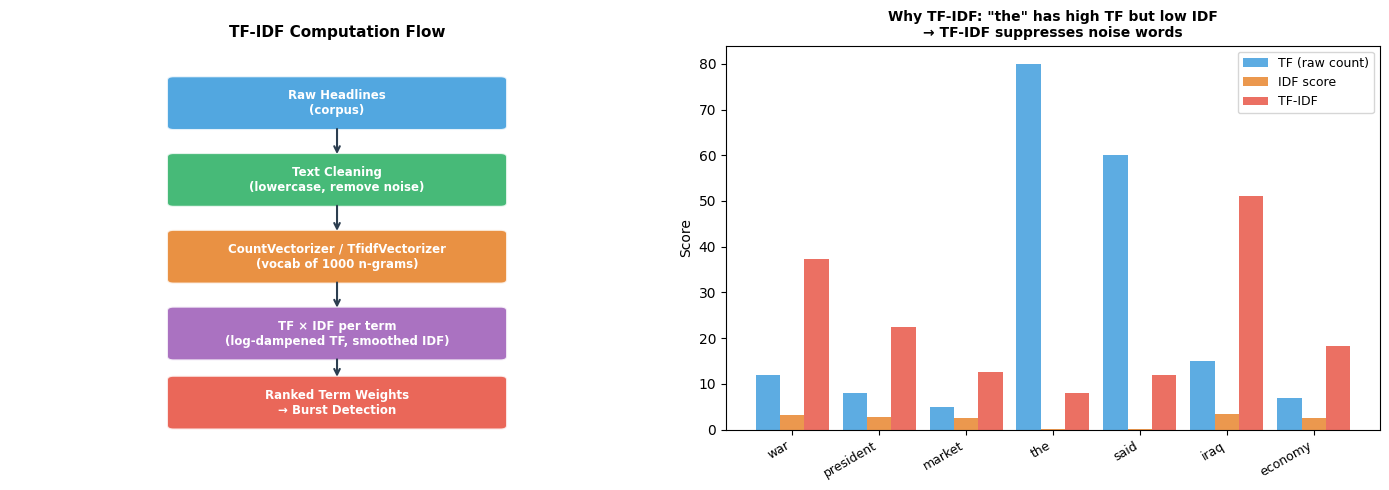

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: TF-IDF computation flow ──────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('TF-IDF Computation Flow', fontweight='bold', fontsize=11)

steps = [
    (5, 8.5, 'Raw Headlines\n(corpus)', '#3498DB'),
    (5, 6.5, 'Text Cleaning\n(lowercase, remove noise)', '#27AE60'),
    (5, 4.5, 'CountVectorizer / TfidfVectorizer\n(vocab of 1000 n-grams)', '#E67E22'),
    (5, 2.5, 'TF × IDF per term\n(log-dampened TF, smoothed IDF)', '#9B59B6'),
    (5, 0.7, 'Ranked Term Weights\n→ Burst Detection', '#E74C3C'),
]
for x, y, label, color in steps:
    box = FancyBboxPatch((x - 2.5, y - 0.6), 5.0, 1.2,
                         boxstyle='round,pad=0.1', facecolor=color,
                         edgecolor='white', linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

for i in range(len(steps) - 1):
    ax.annotate('', xy=(steps[i+1][0], steps[i+1][1] + 0.6),
                xytext=(steps[i][0], steps[i][1] - 0.6),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

# ── Right: TF vs IDF intuition bar chart ───────────────────────────────────
ax2 = axes[1]
terms = ['war', 'president', 'market', 'the', 'said', 'iraq', 'economy']
tf    = [12,    8,           5,         80,    60,     15,     7        ]
idf   = [3.1,   2.8,         2.5,       0.1,   0.2,    3.4,    2.6      ]
tfidf = [t * i for t, i in zip(tf, idf)]

x = np.arange(len(terms))
w = 0.28
ax2.bar(x - w, tf,    w, label='TF (raw count)', color='#3498DB', alpha=0.8)
ax2.bar(x,     idf,   w, label='IDF score',      color='#E67E22', alpha=0.8)
ax2.bar(x + w, tfidf, w, label='TF-IDF',          color='#E74C3C', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(terms, rotation=30, ha='right', fontsize=9)
ax2.set_title('Why TF-IDF: "the" has high TF but low IDF\n→ TF-IDF suppresses noise words',
              fontweight='bold', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_ylabel('Score')

plt.tight_layout()
os.makedirs('reports/baseline', exist_ok=True)
plt.savefig('reports/baseline/tfidf_methodology_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## Implementation

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style='whitegrid')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df = pd.read_csv('data/abcnews-date-text 2.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%Y%m%d')
df['clean_text'] = df['headline_text'].apply(clean_text)
print(f'Loaded {len(df):,} headlines')

Loaded 1,244,184 headlines


In [4]:
# sublinear_tf=True  → log(1+tf) avoids inflating frequent-term weights
# ngram_range=(1,2)  → captures bigrams like 'prime minister', 'stock market'
# min_df=5           → removes very rare (noise) terms
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=50,
)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()

col_sums = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
ranking = (pd.DataFrame({'term': feature_names, 'tfidf_sum': col_sums})
           .sort_values('tfidf_sum', ascending=False)
           .reset_index(drop=True))

print('Top 20 Global Terms:')
display(ranking.head(20))

Top 20 Global Terms:


,term,tfidf_sum
0,police,11374.464379
1,new,10235.071494
2,man,9116.653825
3,interview,8622.192585
4,says,7648.733740
5,australia,6130.039238
6,council,5980.118669
7,court,5919.041927
8,govt,5685.686239
9,nsw,5539.025298


## Temporal Burst Detection

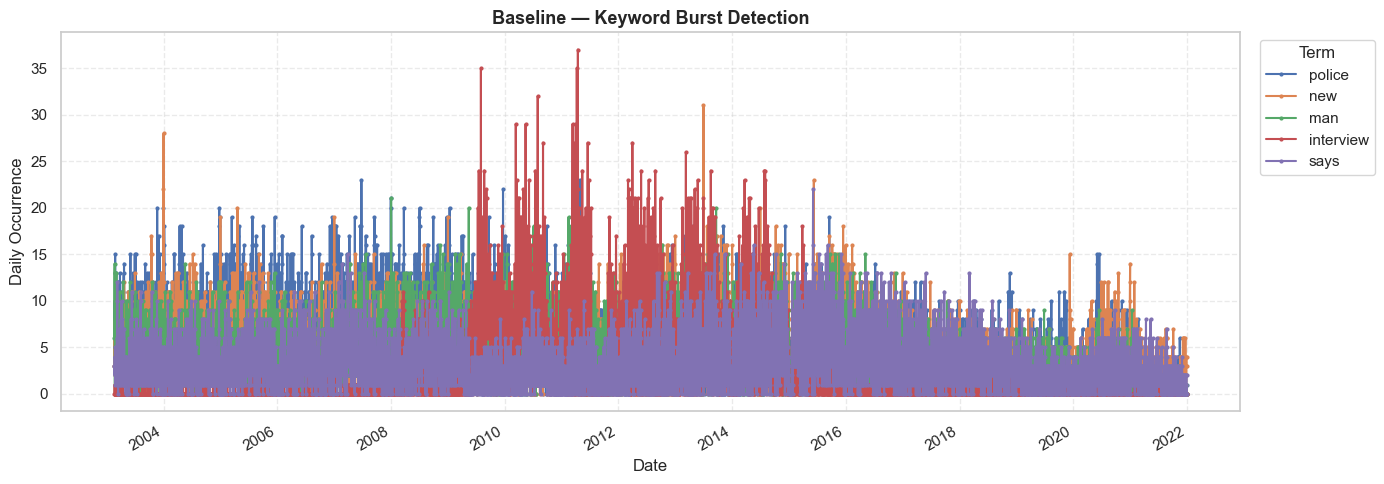

In [5]:
top_keywords = ranking.head(5)['term'].tolist()
df_daily = df.copy()
for kw in top_keywords:
    pattern = r'(?<![a-z])' + re.escape(kw) + r'(?![a-z])'
    df_daily[kw] = df_daily['clean_text'].str.contains(pattern, regex=True).astype(int)

burst_stats = df_daily.groupby('publish_date')[top_keywords].sum()

fig, ax = plt.subplots(figsize=(14, 5))
burst_stats.plot(ax=ax, linewidth=1.5, marker='o', markersize=2)
ax.set_title('Baseline — Keyword Burst Detection', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Occurrence')
ax.set_xlabel('Date')
ax.legend(title='Term', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('reports/baseline/baseline_burst_verification.png', dpi=150)
plt.show()

## Per-Day Top Term Table

In [6]:
daily_top = []
for day in sorted(df['publish_date'].unique())[:15]:
    mask = df['publish_date'] == day
    day_tfidf = vectorizer.transform(df.loc[mask, 'clean_text'])
    day_sums = np.asarray(day_tfidf.sum(axis=0)).flatten()
    best_idx = int(day_sums.argmax())
    daily_top.append({
        'date': day.strftime('%Y-%m-%d'),
        'headlines': int(mask.sum()),
        'top_term': feature_names[best_idx],
        'tfidf_intensity': round(float(day_sums[best_idx]), 4),
    })

results_df = pd.DataFrame(daily_top)
results_df.to_csv('reports/baseline/baseline_verification_results.csv', index=False)
display(results_df)

,date,headlines,top_term,tfidf_intensity
0,2003-02-19,198,funds,3.2480
1,2003-02-20,250,war,4.6443
2,2003-02-21,250,rain,5.7105
3,2003-02-22,126,iraq,2.4268
4,2003-02-23,136,resolution,3.2870
5,2003-02-24,250,rain,7.7588
6,2003-02-25,250,rain,6.0315
7,2003-02-26,250,police,3.7559
8,2003-02-27,221,govt,3.7793
9,2003-02-28,249,iraq,3.0750


## Top 15 Terms — Publication Chart

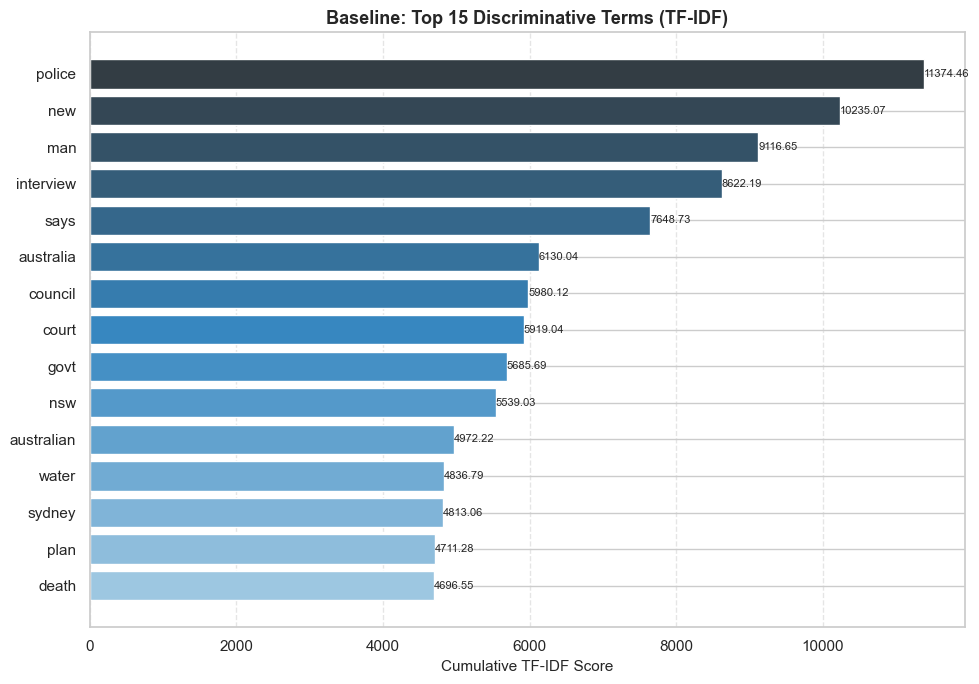

In [7]:
top15 = ranking.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['term'][::-1], top15['tfidf_sum'][::-1],
               color=sns.color_palette('Blues_d', 15))
ax.set_xlabel('Cumulative TF-IDF Score', fontsize=11)
ax.set_title('Baseline: Top 15 Discriminative Terms (TF-IDF)', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('reports/baseline/baseline_top15_terms.png', dpi=150)
plt.show()

## Summary

| Metric | Value |
|---|---|
| Vocabulary size | ~1000 n-grams (capped) |
| Method | TF-IDF with log-TF, bigrams, min_df=5 |
| Verifications | Global ranking, temporal burst chart, per-day top term |

**Limitation found:** TF-IDF ranks individual terms but cannot group semantically related terms into *topics*. For example, 'bush', 'president', 'white house' are ranked separately although they all relate to the same theme.

**Next:** Notebook `03_advanced_ml_lda.ipynb` addresses this with Latent Dirichlet Allocation.